# PCA on Fashion-MNIST

In this project, Principal Component Analysis (PCA) is applied to the Fashion-MNIST dataset for dimensionality reduction and data exploration.

## Objectives
- Visualize high-dimensional image data in 2D
- Understand the structure of the dataset
- Generate new samples using PCA as a generative model

## Methods
- Data preprocessing
- PCA transformation
- 2D visualization of latent space
- Reconstruction and image generation

## Dataset
Fashion-MNIST dataset:
https://github.com/zalandoresearch/fashion-mnist

In [1]:
import platform, socket, getpass
from time import time
from datetime import datetime
import random
signature=[socket.gethostbyname(socket.gethostname()),
           getpass.getuser(),
           datetime.now(),
           random.random()]
print(signature) 

['127.0.0.1', 'yaseminaleyna', datetime.datetime(2026, 3, 25, 21, 4, 26, 924426), 0.9657069468869989]


#### First, we load the dataset

In [2]:
from sklearn.datasets import fetch_openml
fasion_mnist=fetch_openml(name="Fashion-MNIST")

In [3]:
try:
    data=fasion_mnist.data.values
except:
    data=fasion_mnist.data
#data should be numpy array    
images=data.reshape(-1,28,28)
target=fasion_mnist.target.astype('int64')

In [4]:
data.shape

(70000, 784)

In [5]:
images.shape

(70000, 28, 28)

In [6]:
target.shape

(70000,)

In [7]:
[target.min(), target.max()]

[np.int64(0), np.int64(9)]

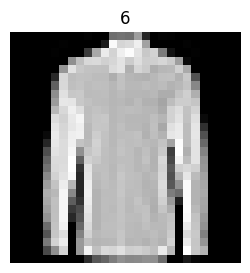

<Figure size 640x480 with 0 Axes>

In [8]:
# show some of the images
import matplotlib.pyplot as plt
from IPython import display
fig, ax = plt.subplots(figsize=(3, 3))
for n in range(0, target.shape[0], 1000):
    x=data[n,:]
    x=x.reshape(28,28) # reshape a vector to an image
    ax.imshow(x, cmap='gray')    
    ax.axis('off')
    ax.set_title(target[n])
    plt.draw()
    display.clear_output(wait=True)
    display.display(fig)
    plt.pause(0.1)  

#### we need the function plot_components for visualization

In [9]:
from matplotlib import offsetbox
import numpy as np
def plot_components(data, model, images, ax=None,
                    thumb_frac=0.05, cmap='gray'):
    ax = ax or plt.gca()
    
    proj = model.fit_transform(data)
    ax.plot(proj[:, 0], proj[:, 1], '.k')
    
    if images is not None:
        min_dist_2 = (thumb_frac * max(proj.max(0) - proj.min(0))) ** 2
        shown_images = np.array([2 * proj.max(0)])
        for i in range(data.shape[0]):
            dist = np.sum((proj[i] - shown_images) ** 2, 1)
            if np.min(dist) < min_dist_2:
                # don't show points that are too close
                continue
            shown_images = np.vstack([shown_images, proj[i]])
            imagebox = offsetbox.AnnotationBbox(
                offsetbox.OffsetImage(images[i], cmap=cmap),
                                      proj[i])
            ax.add_artist(imagebox)

### Your work begins here

In [10]:
#IncrementalPCA (instead of original PCA) in sk-learn
from sklearn.decomposition import IncrementalPCA
ipca = IncrementalPCA(n_components=2, batch_size=200)
proj = ipca.fit_transform(data)

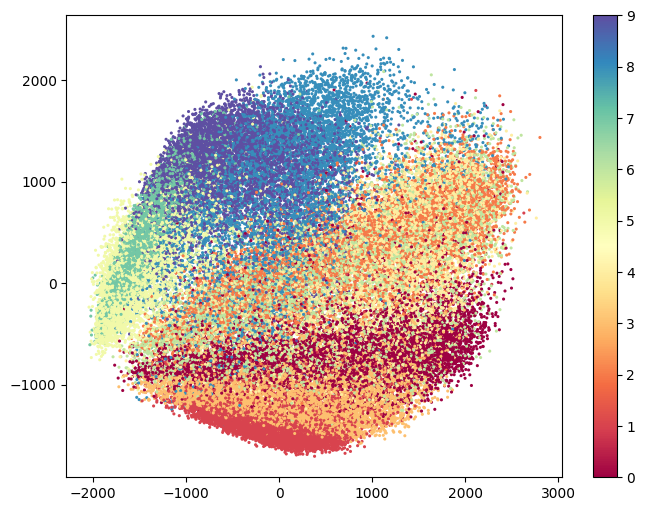

In [11]:
#show the data points in 2D
fig, ax = plt.subplots(figsize=(8,6))

scatter = ax.scatter(proj[:, 0],
                     proj[:, 1],
                     c=target,
                     cmap='Spectral',
                     edgecolor='none',
                     s=5)
fig.colorbar(scatter, ax=ax)

plt.show()

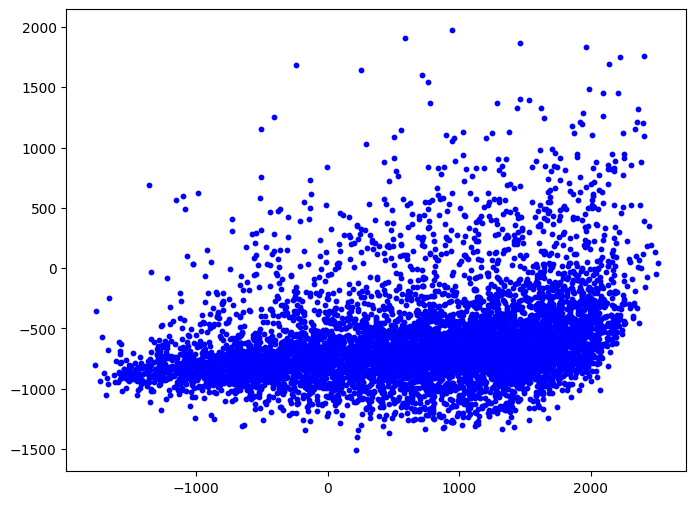

In [12]:
#show only the data points/images with class label=0 in 2D
mask = (target == 0)

fig, ax = plt.subplots(figsize=(8,6))

ax.scatter(proj[mask, 0],
           proj[mask, 1],
           color='blue',
           s=10)
plt.show()

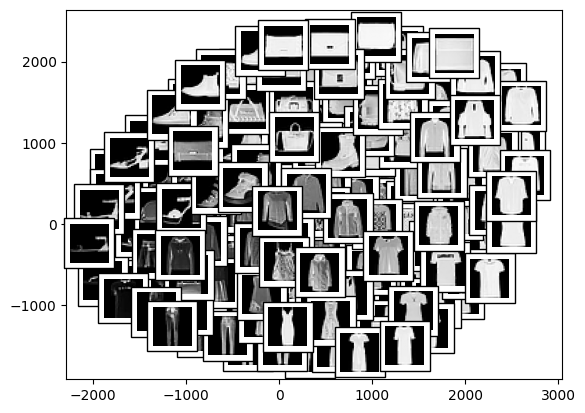

In [13]:
# plot_components to show the data points
plot_components(data, model=ipca, images=images, thumb_frac=0.05, cmap='gray')


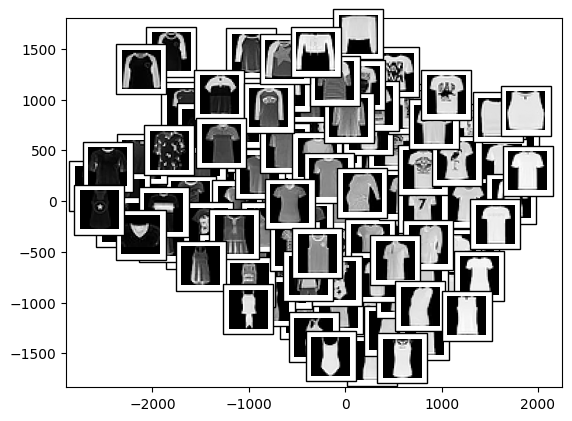

In [14]:
# plot_components to show the data points with class label=0
plot_components(data[target==0], model=ipca, images=images[target==0], thumb_frac=0.05, cmap='gray')

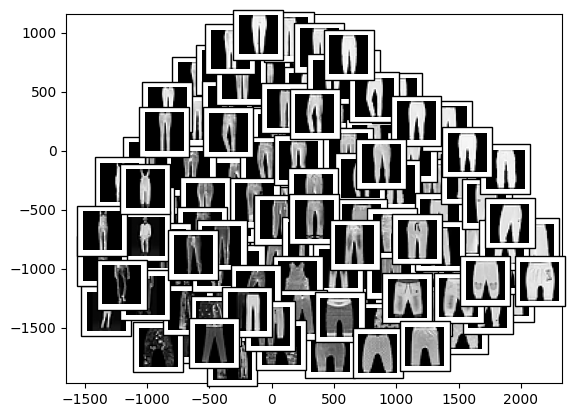

In [15]:
# plot_components to show the data points with class label=1
plot_components(data[target==1], model=ipca, images=images[target==1], thumb_frac=0.05, cmap='gray')

From the above examples, we can see that PCA can extract meaningful features from the images 

### 2. Use PCA to generate new images 

First, we need to figure out how many components we need

In [16]:
from sklearn.decomposition import IncrementalPCA

ipca= IncrementalPCA(n_components=100, batch_size=200)
ipca = ipca.fit(data)

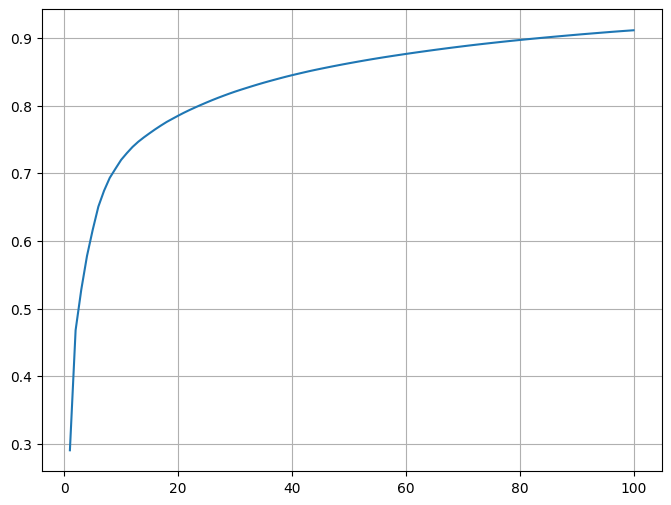

In [17]:
#plot the curve of 'percentage of variance explained' (0~1) vs n_components (0~100)
cumulative_variance = np.cumsum(ipca.explained_variance_ratio_)

# plot
plt.figure(figsize=(8,6))
plt.plot(np.arange(1, 101), cumulative_variance)
plt.grid(True)
plt.show()

In [18]:
n_components_80 = np.where(cumulative_variance >= 0.8)[0][0] + 1  

print(f"Smallest n_components for >=80% variance: {n_components_80}")

Smallest n_components for >=80% variance: 24


In [19]:
# get the mean, eigenvalues, and eigenvectors from the pca model

# mean of the data
mu = ipca.mean_           # shape: (n_features,)

# eigenvalues
v = ipca.explained_variance_   # shape: (n_components,)

# eigenvectors
w = ipca.components_      # shape: (n_components, n_features)

In [20]:
v.shape

(100,)

In [21]:
w.shape

(100, 784)

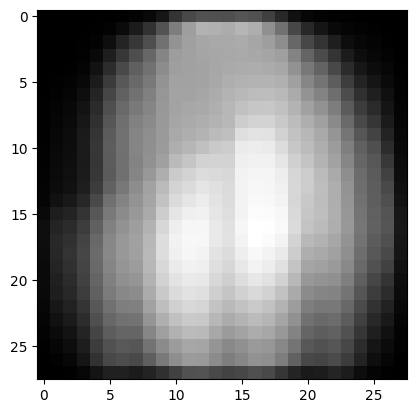

In [22]:
# plot the mean image from pca
plt.imshow(mu.reshape(28,28), cmap='gray')

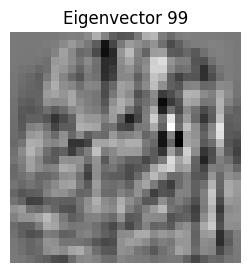

<Figure size 640x480 with 0 Axes>

In [23]:
# use a for loop to show the images of eigenvectors
fig, ax = plt.subplots(figsize=(3, 3))

for n in range(0, 100):
    ax.imshow(w[n].reshape(28, 28), cmap='gray')  # eigenvector
    ax.axis('off')
    ax.set_title(f"Eigenvector {n}")
    
    plt.draw()
    display.clear_output(wait=True)  
    display.display(fig)             
    plt.pause(0.2)             

In [24]:
# L2 norm of an eigenvector w[0]
np.sum(w[0]**2)

np.float64(0.9999999999999998)

In [25]:
# generate a random number
3*np.random.randn()

-0.15422205641847828

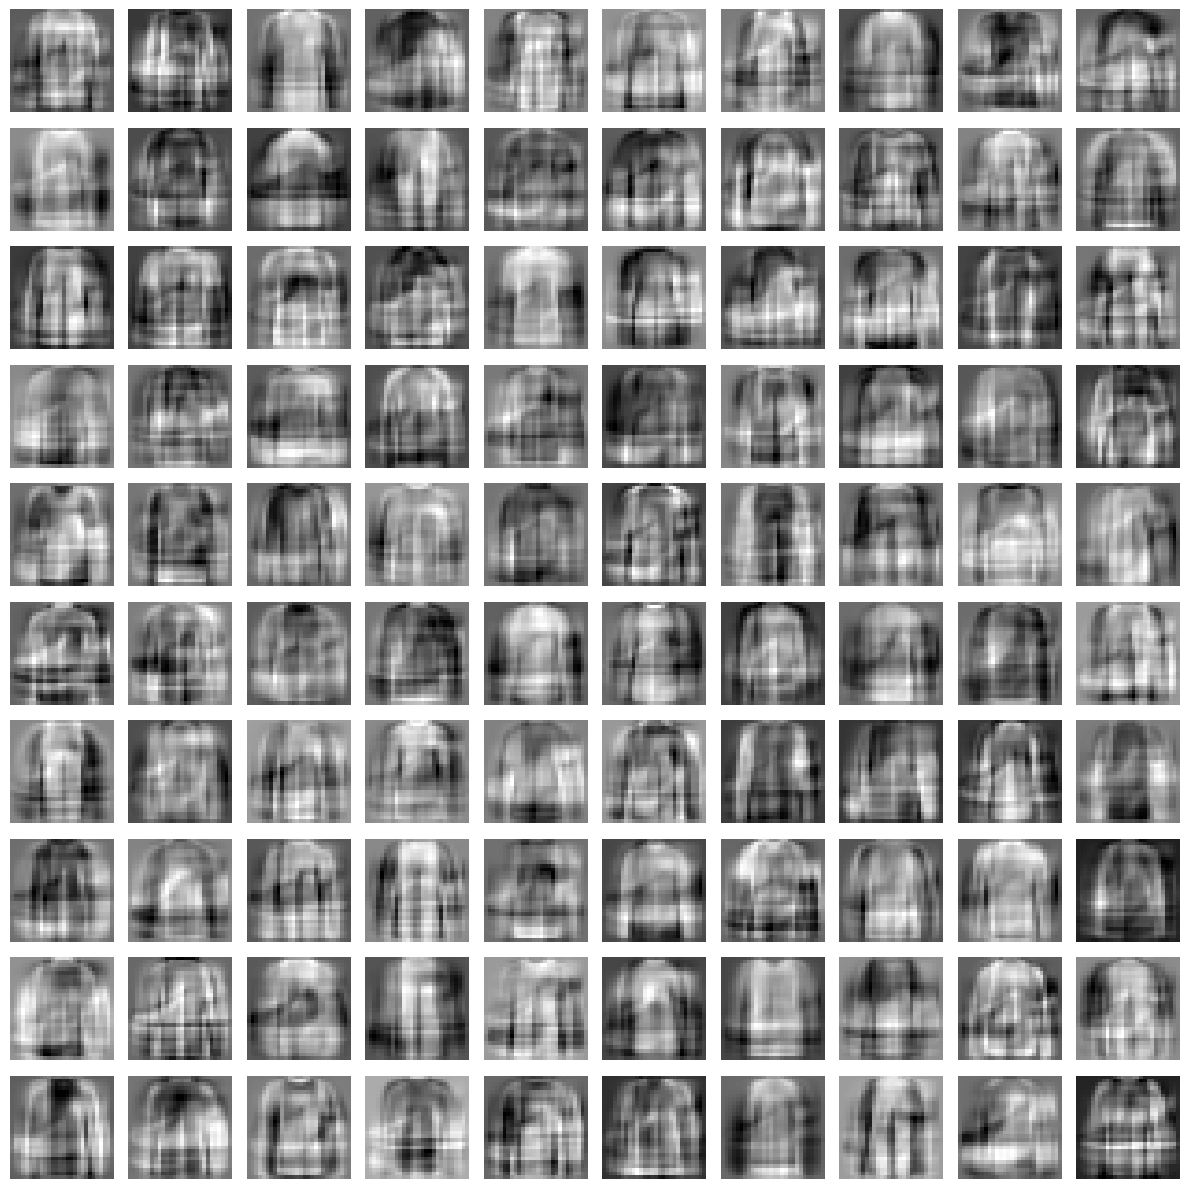

In [26]:
# generate and show the new images
K = 100  # number of PCA
num_images = 100  # number of generated new images

fig, axes = plt.subplots(10, 10, figsize=(12, 12))
axes = axes.flatten()

for i in range(num_images):
    x_new = mu.copy()  # mean vector
    for k in range(K):
        y_k = 3 * np.random.randn()        # random coefficient
        x_new += y_k * np.sqrt(v[k]) * w[k]  # multiplied with eigenvector and add

  
    axes[i].imshow(x_new.reshape(28, 28), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### t-SNE for visualization

In [27]:
#select a subset of data points for TSNE
data_s=data[0::100]
target_s=target[0::100]
images_s=images[0::100]

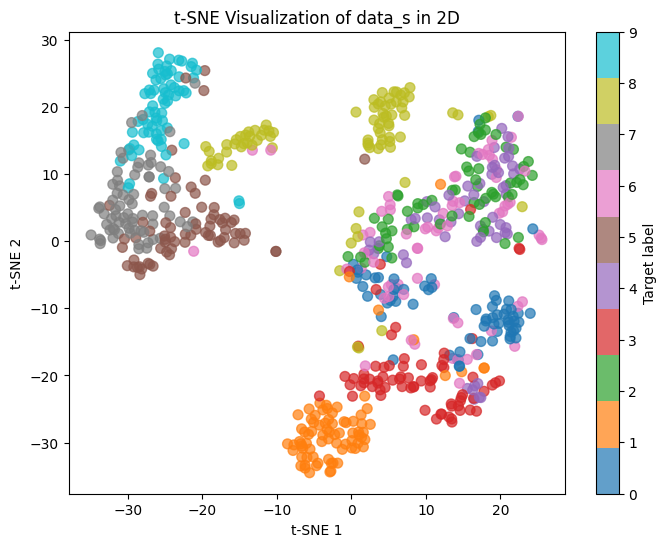

In [29]:
# Run t-SNE on the subset
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)  # random_state for reproducibility
data_tsne = tsne.fit_transform(data_s)

# Scatter plot 
plt.figure(figsize=(8,6))
scatter = plt.scatter(data_tsne[:, 0], data_tsne[:, 1], c=target_s, cmap='tab10', s=50, alpha=0.7)
plt.title("t-SNE Visualization of data_s in 2D")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(scatter, label='Target label')
plt.show()